## Model 1: Static table model (Stan)

**Idea:** fit on **historical league tables** plus **process features** from match data.  
The model outputs a **predicted end-of-season table** directly.

**Backtest:** train on tables through 2024/25 → predict table 2025/26 (`2526`).

### Technical description

For each team-season row:

$$\text{Pts} \sim t_{\nu}\big(\alpha + \beta \cdot \text{skill}_t + \gamma_1 \cdot \text{sot\_diff} + \gamma_2 \cdot \text{pts\_lag1} + \gamma_3 \cdot \text{ppg\_last10} + \gamma_4 \cdot \text{is\_promoted},\; \sigma_{\text{pts}}\big)$$

Student-$t$ likelihood with $\nu=5$ fixed (robust to outlier seasons; standard choice in robust regression).

| Feature | Meaning |
|---------|---------|
| `sot_diff_pg` | (shots on target for − against) per match |
| `pts_lag1` | points in previous season (0 if promoted) |
| `ppg_last10` | points per game in last 10 matchdays |
| `is_promoted` | 1 for promoted/new teams in the target season, otherwise 0 |

Covariates are **z-scored** on training data.  
**Forecast:** use covariates from the **last training season** (2425), sample points, **rank** → table.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    build_forecast_features,
    compute_table,
    predict_table,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [11]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
FEATURE_SEASON = "2425"  # last training season → covariates for 2526 forecast

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, feature_stats = prepare_table_stan_static(
    tables, TRAIN_SEASONS
)
stan_data["nu"] = STUDENT_T_NU  # required by table_static.stan (Student-t df)
test_teams = sorted(teams_in_season(matches, TEST_SEASON))

print(f"Training rows (team-seasons): {stan_data['N']}")
print(f"Stan keys: {sorted(stan_data.keys())}")
print(f"Teams in training: {stan_data['T']}")
print(f"Test season {TEST_SEASON}: {len(test_teams)} teams")
print(tables.groupby('season')['Pts'].mean().tail(3))
print("\nFeature ranges (raw, training seasons):")
print(tables[['sot_diff_pg', 'pts_lag1', 'ppg_last10']].describe().round(2))

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / new teams (is_promoted=1, skill=0, covariates=training mean):", new_in_test)


Training rows (team-seasons): 320
Stan keys: ['N', 'T', 'is_promoted', 'nu', 'ppg_last10', 'pts', 'pts_lag1', 'sot_diff_pg', 'team']
Teams in training: 42
Test season 2526: 20 teams
season
2223    52.65
2324    52.90
2425    52.35
Name: Pts, dtype: float64

Feature ranges (raw, training seasons):
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.30     45.02        1.21
std           1.70     26.80        0.78
min          -3.76      0.00        0.00
25%          -0.74     38.00        0.70
50%           0.00     47.00        1.30
75%           1.14     63.25        1.80
max           6.03    100.00        3.00


### Prior selection

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `intercept` | $\mathcal{N}(52, 10)$ | Baseline around the average points total in a 20-team league. |
| `beta_pts` | $\mathcal{N}(20, 10)$, truncated at 0 by Stan support | Converts one unit of latent static team strength into points. Positive support fixes the skill direction. |
| `beta_sot`, `beta_form` | $\mathcal{N}(0, 8)$ | Process/form effects on z-scored inputs; broad enough for several points per one SD move. |
| `beta_lag` | $\mathcal{N}(0, 0.5)$ | Conservative effect for previous-season points because much of persistent strength is already in `skill`. |
| `beta_promoted` | $\mathcal{N}(-10, 5)$ | Promoted teams usually start below established Premier League teams; still allows weak or near-zero penalty. |
| `log_sigma_pts` | $\mathcal{N}(\log 17, 0.3)$ with bounds | Residual table-points scale, sampled on log scale for positive and stable geometry. |
| `nu` | fixed at 5 | Student-$t$ df; heavier tails than Normal for unusual seasons. |
| `skill` | sum-to-zero standard Normal vector | Latent static team strength; centered so `intercept` remains interpretable. |

**Input data:** `Pts` is the target. Predictors are lag-safe `sot_diff_pg`, `pts_lag1`, `ppg_last10`, and `is_promoted`.

The prior parameters were selected from domain scale rather than from the held-out season: a mid-table team has about 50 points, full-table residual spread can be around 15-20 points, promoted sides often lose roughly one-digit to low-double-digit points relative to established sides, and covariates are z-scored so coefficient priors are directly on the points scale.


,0.05,0.50,0.95
intercept,35.134885,51.958390,68.162429
beta_pts,5.162381,20.008527,36.775109
beta_sot,-13.006977,-0.181564,13.543648
beta_lag,-0.797186,0.022081,0.859734
beta_form,-13.116423,0.128868,13.280626
beta_promoted,-18.360838,-9.883880,-1.512189
sigma_pts,10.427716,16.791597,26.027879
skill_range,3.374068,4.334695,5.542275


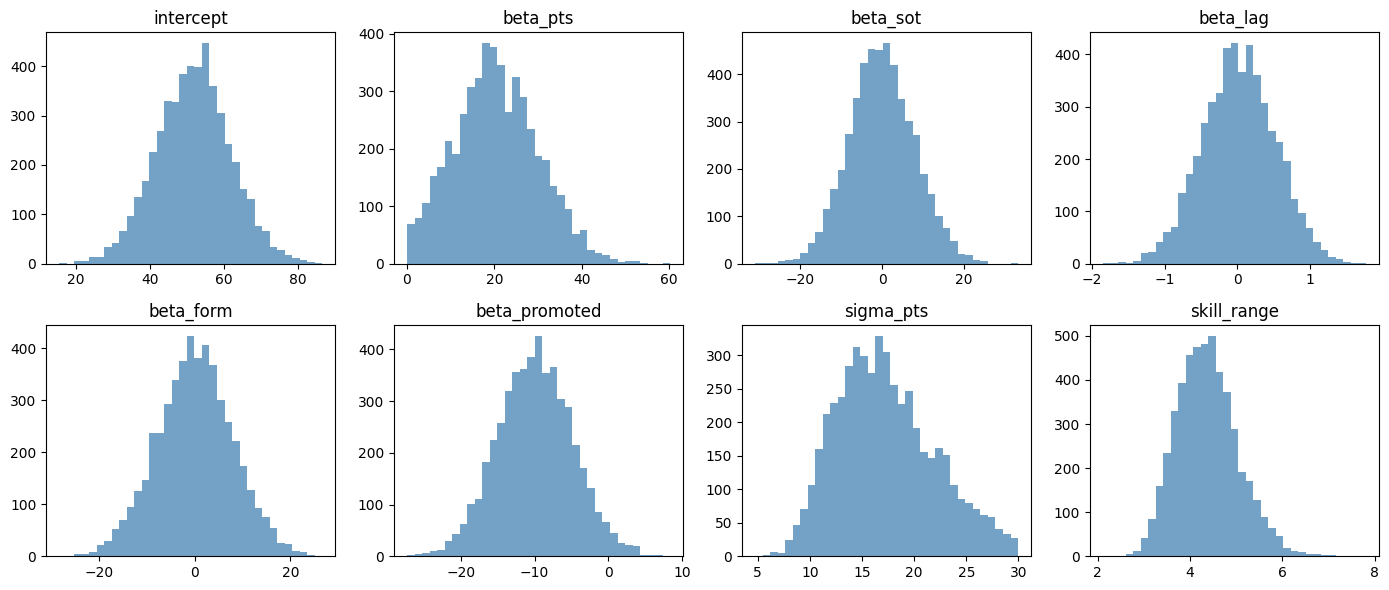

Prior points mean: 51.5; observed mean: 52.4
Prior central 90% interval: -8.7 to 109.1
Observed range: 12 to 100


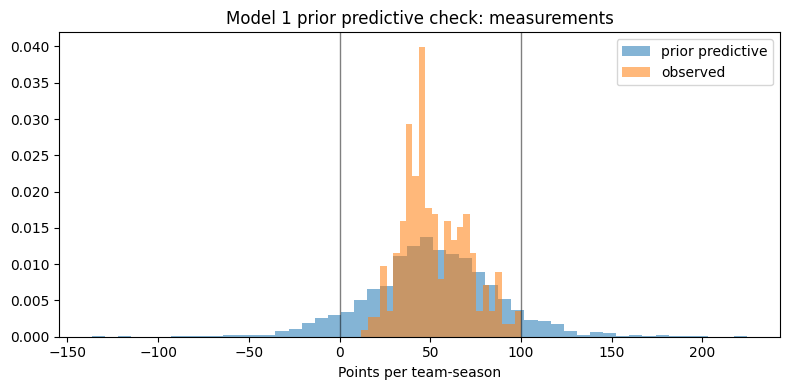

In [12]:
# Prior predictive checks: parameters and generated team-season points
rng = np.random.default_rng(42)
n_prior = 5000
T = stan_data["T"]
nu_prior = STUDENT_T_NU

def rtrunc_normal(mean, sd, lower=-np.inf, upper=np.inf, size=1):
    out = np.empty(size)
    filled = 0
    while filled < size:
        draws = rng.normal(mean, sd, size - filled)
        draws = draws[(draws >= lower) & (draws <= upper)]
        take = min(len(draws), size - filled)
        if take:
            out[filled:filled + take] = draws[:take]
            filled += take
    return out

intercept_p = rng.normal(52, 10, n_prior)
beta_pts_p = rtrunc_normal(20, 10, lower=0, size=n_prior)
beta_sot_p = rng.normal(0, 8, n_prior)
beta_lag_p = rng.normal(0, 0.5, n_prior)
beta_form_p = rng.normal(0, 8, n_prior)
beta_promoted_p = rng.normal(-10, 5, n_prior)
log_sigma_p = rtrunc_normal(np.log(17), 0.3, lower=np.log(0.5), upper=np.log(30), size=n_prior)
sigma_p = np.exp(log_sigma_p)

skill_p = rng.normal(0, 1, (n_prior, T))
skill_p -= skill_p.mean(axis=1, keepdims=True)

prior_params = pd.DataFrame({
    "intercept": intercept_p,
    "beta_pts": beta_pts_p,
    "beta_sot": beta_sot_p,
    "beta_lag": beta_lag_p,
    "beta_form": beta_form_p,
    "beta_promoted": beta_promoted_p,
    "sigma_pts": sigma_p,
    "skill_range": skill_p.max(axis=1) - skill_p.min(axis=1),
})
display(prior_params.quantile([0.05, 0.5, 0.95]).T)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), prior_params.columns):
    ax.hist(prior_params[col], bins=35, color="steelblue", alpha=0.75)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Measurement prior predictive: sample realistic covariate rows from the training design.
idx = rng.integers(0, stan_data["N"], size=3000)
draw = rng.integers(0, n_prior, size=3000)
teams = np.asarray(stan_data["team"])[idx] - 1
mu_prior = (
    intercept_p[draw]
    + beta_pts_p[draw] * skill_p[draw, teams]
    + beta_sot_p[draw] * np.asarray(stan_data["sot_diff_pg"])[idx]
    + beta_lag_p[draw] * np.asarray(stan_data["pts_lag1"])[idx]
    + beta_form_p[draw] * np.asarray(stan_data["ppg_last10"])[idx]
    + beta_promoted_p[draw] * np.asarray(stan_data["is_promoted"])[idx]
)
pts_prior = mu_prior + sigma_p[draw] * rng.standard_t(nu_prior, size=len(draw))

print(f"Prior points mean: {pts_prior.mean():.1f}; observed mean: {np.mean(stan_data['pts']):.1f}")
print(f"Prior central 90% interval: {np.quantile(pts_prior, 0.05):.1f} to {np.quantile(pts_prior, 0.95):.1f}")
print(f"Observed range: {np.min(stan_data['pts']):.0f} to {np.max(stan_data['pts']):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(pts_prior, bins=50, density=True, alpha=0.55, label="prior predictive")
plt.hist(stan_data["pts"], bins=25, density=True, alpha=0.55, label="observed")
plt.axvline(0, color="black", lw=1, alpha=0.5)
plt.axvline(100, color="black", lw=1, alpha=0.5)
plt.xlabel("Points per team-season")
plt.title("Model 1 prior predictive check: measurements")
plt.legend()
plt.tight_layout()
plt.show()


**Prior predictive interpretation (Model 1):** the parameter prior should allow realistic but not absurd league tables. The measurement check is intentionally broad: before seeing the likelihood, simulated points may extend outside 0-100, but most mass should sit around plausible Premier League season totals. If this plot places too much mass on impossible seasons, the next adjustment should be `sigma_pts`, `beta_pts`, or the promoted-team prior, not the held-out data.

### Fit Stan model (`stan/table_static.stan`)


In [13]:
model = CmdStanModel(stan_file="stan/table_static.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


16:03:09 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:03:13 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check `fit.diagnose()` for divergences, $\hat{R}$, and ESS (effective sample size).
Target: no divergences, $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$.


                     Mean      MCSE    StdDev       MAD          5%  \
intercept       50.269600  0.028922  1.062150  1.089120   48.556200   
beta_pts         7.694330  0.054748  1.470190  1.418320    5.415780   
beta_sot         6.323880  0.023300  1.025000  1.030890    4.686980   
beta_lag         0.005154  0.006986  0.483087  0.493880   -0.797599   
beta_form        1.131670  0.016663  1.009030  1.003840   -0.546700   
beta_promoted   -8.980260  0.045258  2.351590  2.368390  -12.897300   
sigma_pts        8.847330  0.007664  0.460067  0.461192    8.111040   
lp__          -917.384000  0.326219  7.669790  7.756220 -930.293000   

                      50%         95%  ESS_bulk  ESS_tail    R_hat  
intercept       50.272000   52.019200  1362.500   2515.02  1.00115  
beta_pts         7.622330   10.159200   742.851   1623.92  1.00280  
beta_sot         6.314840    8.039540  1952.450   2257.77  1.00054  
beta_lag         0.005268    0.815688  4848.700   2963.79  1.00065  
beta_form      

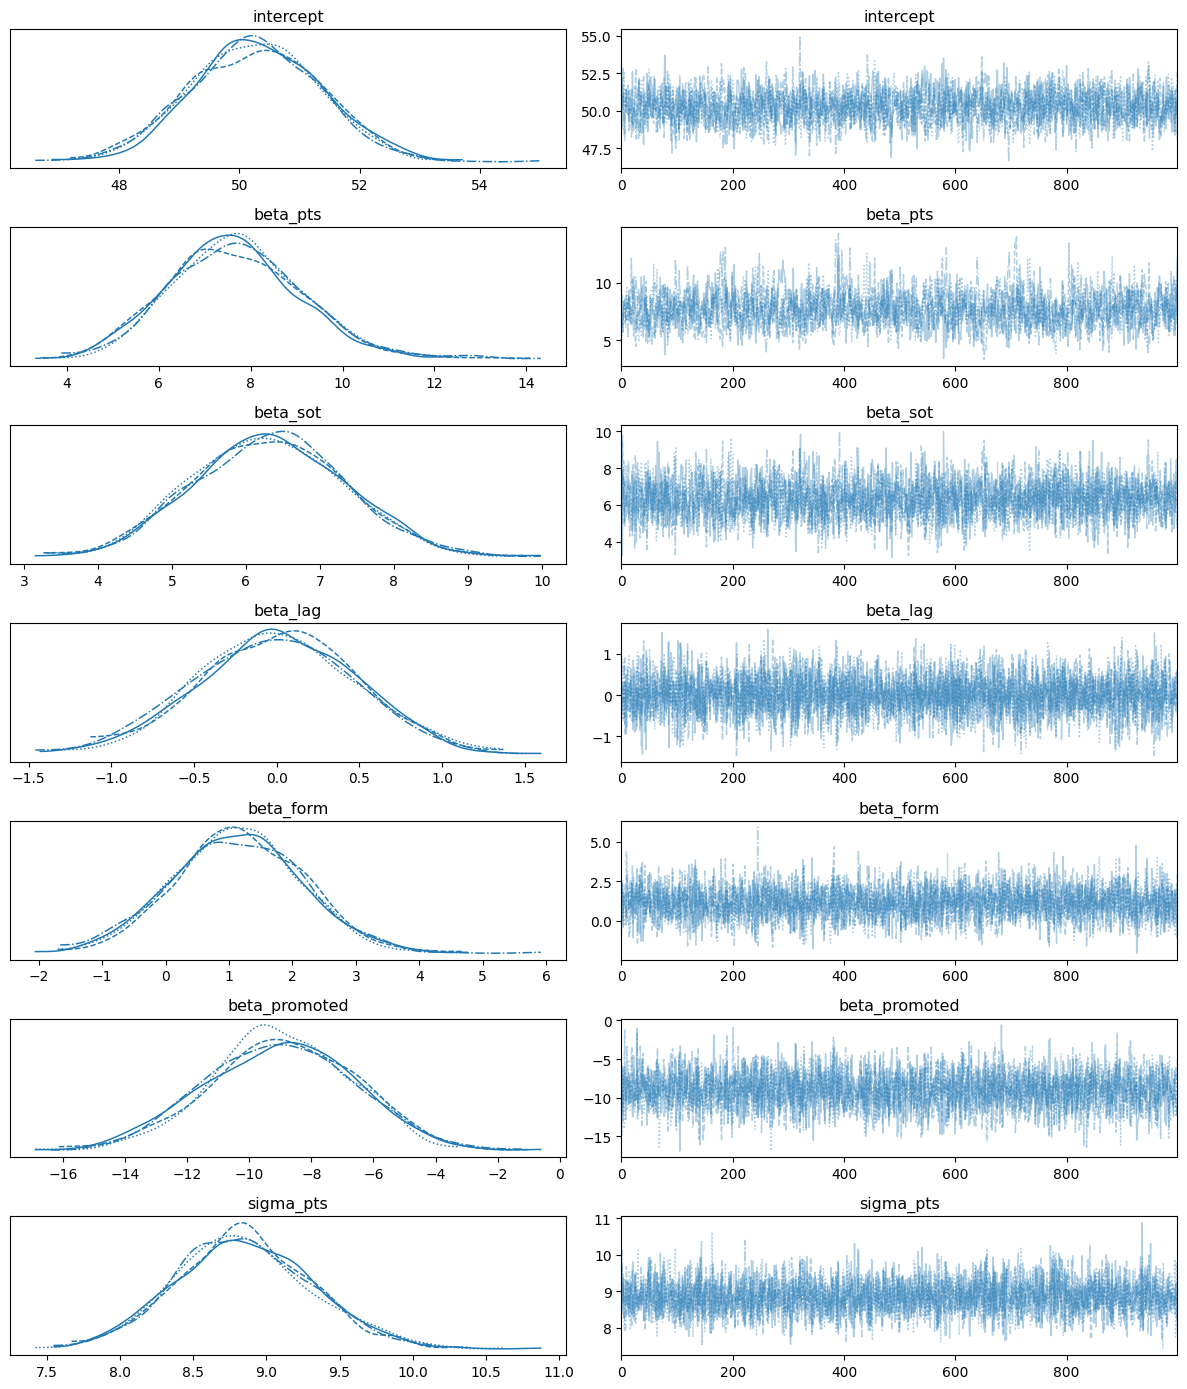

In [14]:
param_vars = [
    "intercept", "beta_pts", "beta_sot", "beta_lag", "beta_form", "beta_promoted", "sigma_pts"
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
print(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    print(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    print(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


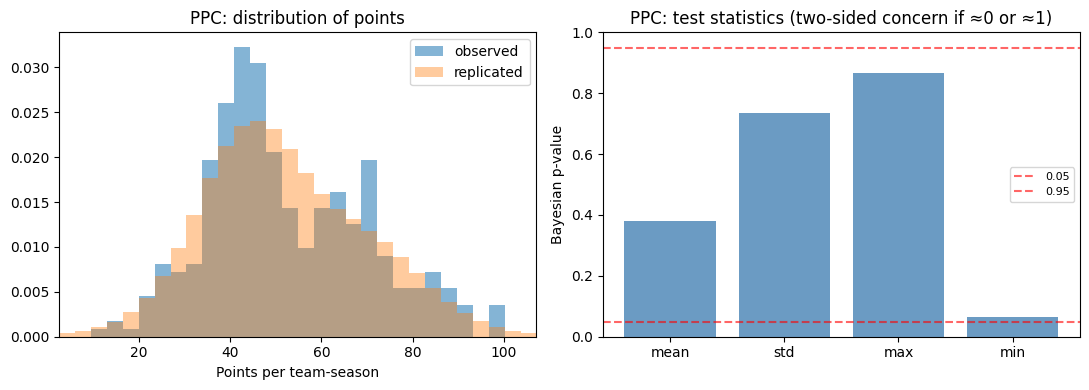

PPC x-axis shown: 2.6 to 107.1 points
Replicated draws outside shown range: 0.54%
  mean: p = 0.381
  std: p = 0.736
  max: p = 0.865
  min: p = 0.065


In [15]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="static")
y_rep_flat = y_rep.reshape(-1)

# Focus the PPC plot on the observed range and the central model mass.
# Student-t tails can create rare extreme draws that otherwise stretch the x-axis.
q_low, q_high = np.quantile(y_rep_flat, [0.005, 0.995])
plot_low = max(0, min(y_obs.min(), q_low) - 5)
plot_high = min(110, max(y_obs.max(), q_high) + 5)
bins = np.linspace(plot_low, plot_high, 31)
outside = np.mean((y_rep_flat < plot_low) | (y_rep_flat > plot_high))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=bins, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep_flat, bins=bins, density=True, alpha=0.4, label="replicated")
axes[0].set_xlim(plot_low, plot_high)
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points")
axes[0].legend()

stats = {
    "mean": np.mean,
    "std": np.std,
    "max": np.max,
    "min": np.min,
}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6, label="0.05")
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6, label="0.95")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics (two-sided concern if ≈0 or ≈1)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PPC x-axis shown: {plot_low:.1f} to {plot_high:.1f} points")
print(f"Replicated draws outside shown range: {100 * outside:.2f}%")
for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 1):** overlapping histograms and $p$-values not extreme (roughly 0.1–0.9) indicate the Student-$t$ model reproduces the scale and spread of historical points. Large discrepancies would suggest revising covariates or $\nu$.


### Latent team skills (static)


In [16]:
skill_mean = fit.stan_variable("skill").mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

strengths = pd.DataFrame({
    "team": [idx_to_team[j + 1] for j in range(len(skill_mean))],
    "skill": skill_mean,
}).sort_values("skill", ascending=False)

strengths.head(10)


,team,skill
22,Man City,2.388119
23,Man United,1.791427
0,Arsenal,1.693787
20,Liverpool,1.446871
11,Chelsea,1.400934
36,Tottenham,1.356412
7,Brentford,0.543707
33,Stoke,0.389747
1,Aston Villa,0.298266
25,Newcastle,0.257344


### Predict table 2025/26


In [17]:
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

pred_table = predict_table(
    fit,
    test_teams,
    team_to_idx,
    model="static",
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)
pred_summary = pred_table

actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_table.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
1,Arsenal,4.0,4.724,68.872052,69.062813,1,85,3.0
0,Man City,2.0,2.762,77.322207,77.332293,2,78,0.0
4,Man United,5.0,6.218,64.646646,64.666309,3,71,2.0
6,Aston Villa,10.0,10.166,55.004282,54.283685,4,65,6.0
2,Liverpool,4.0,4.372,70.457940,70.320063,5,60,-1.0
8,Bournemouth,11.0,10.942,52.022385,52.678240,6,57,5.0
18,Sunderland,18.0,16.128,37.987063,38.775027,7,54,11.0
7,Brighton,10.0,10.616,53.444665,53.272365,8,53,2.0
11,Brentford,12.0,11.364,51.639358,51.430745,9,53,3.0
3,Chelsea,5.0,5.436,67.209722,66.647414,10,52,-5.0


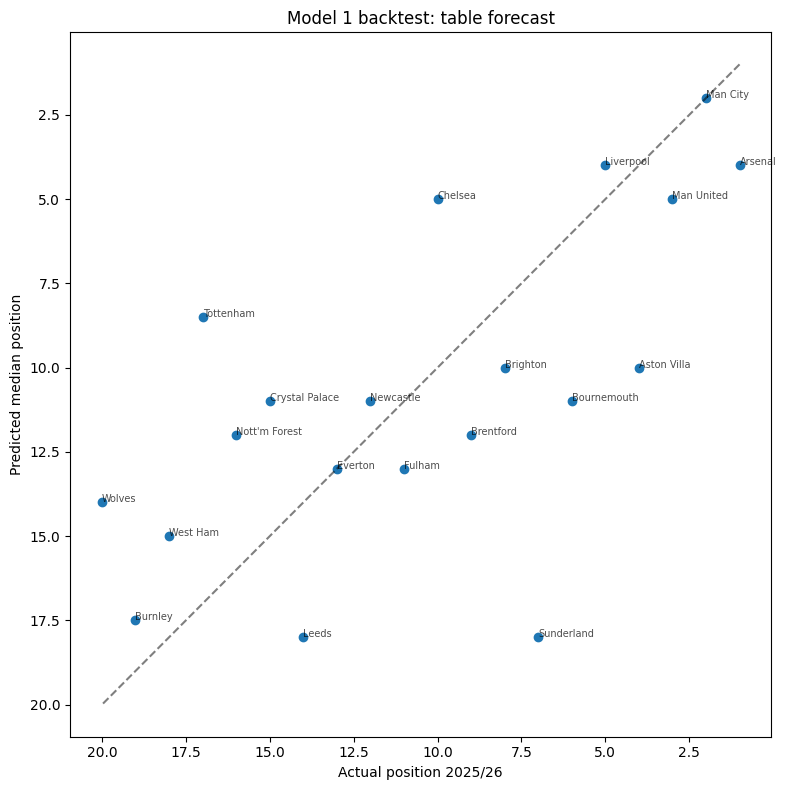

Mean absolute position error: 3.60


In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position")
ax.set_title("Model 1 backtest: table forecast")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mae_pos = comparison["pos_error"].abs().mean()
print(f"Mean absolute position error: {mae_pos:.2f}")


**Interpretation:** the model never simulates individual matches — it predicts **points**, then **ranks** teams into a table.
